# Estadística bayesiana aplicada a confiabilidad y mantenibilidad
## Estimación de parámetros para modelos Exponencial, Weibull y Lognormal

**Nivel:** intermedio  
**Caso conductor:** bomba centrífuga BP-101  
**Objetivo:** construir la inferencia paso a paso, desde los datos hasta la distribución posterior y la predicción de confiabilidad o mantenibilidad.

> **Nota:** los datos de este notebook son sintéticos y se usan exclusivamente con fines docentes. El análisis no reemplaza la validación de ingeniería, los procedimientos de integridad ni el juicio experto.

### Resultados de aprendizaje
1. Interpretar prior, verosimilitud, posterior y distribución predictiva.
2. Comprender por qué una familia es conjugada.
3. Resolver exactamente el modelo Gamma–Exponencial.
4. Reconocer la conjugación condicional del modelo Weibull cuando la forma es conocida.
5. Estimar conjuntamente forma y escala Weibull mediante una grilla posterior.
6. Resolver el modelo Normal–Gamma inversa para datos Lognormales.
7. Comparar estimación bayesiana y máxima verosimilitud.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, special
from scipy.optimize import minimize
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

RNG = np.random.default_rng(2026)
COLORS = {"navy":"#173B57", "blue":"#2683C6", "light":"#9AC8E5", "orange":"#F2A23A", "red":"#C74B50", "green":"#20856C", "gray":"#687780"}
CMAP = LinearSegmentedColormap.from_list("bayes", ["#F7FAFC", "#9AC8E5", "#2683C6", "#173B57"])
plt.rcParams.update({"figure.figsize":(10,5), "axes.grid":True, "grid.alpha":0.22, "grid.linestyle":"--", "axes.spines.top":False, "axes.spines.right":False, "font.size":11})

def hdi(samples, prob=0.95):
    x=np.sort(np.asarray(samples)); m=int(np.floor(prob*len(x)))
    widths=x[m:]-x[:len(x)-m]; i=np.argmin(widths)
    return x[i], x[i+m]

def summary(samples, name):
    lo,hi=hdi(samples)
    return pd.Series({"media":np.mean(samples), "mediana":np.median(samples), "desv":np.std(samples), "HDI 2.5%":lo, "HDI 97.5%":hi}, name=name)

## 1. Del razonamiento probabilístico a la inferencia

Sea $\theta$ un parámetro desconocido y $D$ el conjunto de datos. Bayes combina tres elementos:

$$
\underbrace{p(\theta\mid D)}_{\text{posterior}}
=\frac{\underbrace{p(D\mid\theta)}_{\text{verosimilitud}}\underbrace{p(\theta)}_{\text{prior}}}
{\underbrace{p(D)}_{\text{evidencia}}}.
$$

En estimación de parámetros, normalmente basta trabajar con la proporcionalidad:

$$p(\theta\mid D)\propto p(D\mid\theta)p(\theta).$$

### ¿Qué significa conjugación?
Una prior es **conjugada** para una verosimilitud cuando la posterior pertenece a la misma familia de distribuciones que la prior. No significa que prior y datos sean iguales. Significa que el núcleo algebraico se conserva.

**Ventajas:**
- posterior analítica;
- actualización secuencial sencilla;
- interpretación mediante observaciones equivalentes;
- menor costo computacional.

**Limitación:** la conveniencia matemática no es una justificación científica del prior. La fuente y la fuerza del prior deben documentarse y someterse a análisis de sensibilidad.

## 2. Datos del caso integral

Se simulan tres fuentes relacionadas:

- **Exposición agregada:** fallas y horas totales para un modelo Exponencial.
- **Tiempos de vida individuales:** fallas y observaciones censuradas para Weibull.
- **Tiempos de reparación:** duraciones positivas y asimétricas para Lognormal.

In [2]:
# Datos sintéticos, fijados para que el notebook sea reproducible
exp_data = pd.DataFrame({"periodo":["P1","P2","P3"], "fallas":[2,2,2], "horas_exposicion":[5200,6800,6000]})
weibull_data = pd.DataFrame({
    "equipo":[f"BP-{i:02d}" for i in range(1,13)],
    "tiempo_h":[2450,3380,4210,5120,5980,6850,7440,8120,9000,9000,9000,9000],
    "evento":[1,1,1,1,1,1,1,1,0,0,0,0]
})
repair_data = pd.DataFrame({"orden":[f"OT-{i:03d}" for i in range(1,11)], "ttr_h":[3.2,5.1,4.5,7.8,6.2,4.9,3.8,8.6,5.7,4.1]})
print("Exponencial")
display(exp_data)
print("Weibull: evento=1 falla; evento=0 censura a la derecha")
display(weibull_data)
print("Lognormal: tiempos de reparación")
display(repair_data)

Exponencial


,periodo,fallas,horas_exposicion
0,P1,2,5200
1,P2,2,6800
2,P3,2,6000


Weibull: evento=1 falla; evento=0 censura a la derecha


,equipo,tiempo_h,evento
0,BP-01,2450,1
1,BP-02,3380,1
2,BP-03,4210,1
3,BP-04,5120,1
4,BP-05,5980,1
5,BP-06,6850,1
6,BP-07,7440,1
7,BP-08,8120,1
8,BP-09,9000,0
9,BP-10,9000,0


Lognormal: tiempos de reparación


,orden,ttr_h
0,OT-001,3.2
1,OT-002,5.1
2,OT-003,4.5
3,OT-004,7.8
4,OT-005,6.2
5,OT-006,4.9
6,OT-007,3.8
7,OT-008,8.6
8,OT-009,5.7
9,OT-010,4.1


# Parte A. Modelo Exponencial con prior Gamma

## 3. Modelo y función de confiabilidad

Para tiempos de vida independientes con tasa constante $\lambda$:

$$f(t\mid\lambda)=\lambda e^{-\lambda t},\qquad R(t\mid\lambda)=e^{-\lambda t},\qquad h(t)=\lambda.$$

Si observamos $r$ fallas durante una exposición total $T$, incluyendo exposición censurada, la verosimilitud es:

$$L(\lambda\mid D)\propto \lambda^r e^{-\lambda T}.$$

Usaremos la convención Gamma **forma–tasa**:

$$\lambda\sim\operatorname{Gamma}(\alpha_0,\beta_0),\qquad
p(\lambda)=\frac{\beta_0^{\alpha_0}}{\Gamma(\alpha_0)}\lambda^{\alpha_0-1}e^{-\beta_0\lambda}.$$

Multiplicando prior y verosimilitud:

$$p(\lambda\mid D)\propto
\lambda^{\alpha_0-1+r}e^{-(\beta_0+T)\lambda},$$

por tanto:

$$\boxed{\lambda\mid D\sim\operatorname{Gamma}(\alpha_0+r,\beta_0+T)}.$$

La actualización tiene una lectura directa: **se suman fallas a la forma y horas a la tasa**.

In [3]:
r = exp_data["fallas"].sum()
T = exp_data["horas_exposicion"].sum()
alpha0, beta0 = 3.0, 15000.0
alpha_n, beta_n = alpha0+r, beta0+T
lambda_mle = r/T
lambda_post_mean = alpha_n/beta_n
print(f"Fallas r = {r}; exposición T = {T:,.0f} h")
print(f"Prior: Gamma({alpha0:.1f}, {beta0:,.0f})")
print(f"Posterior: Gamma({alpha_n:.1f}, {beta_n:,.0f})")
print(f"λ MLE = {lambda_mle:.6f}/h; λ posterior media = {lambda_post_mean:.6f}/h")
print(f"MTBF plug-in MLE = {1/lambda_mle:,.0f} h")
print(f"1/E[λ|D] = {1/lambda_post_mean:,.0f} h")

Fallas r = 6; exposición T = 18,000 h
Prior: Gamma(3.0, 15,000)
Posterior: Gamma(9.0, 33,000)
λ MLE = 0.000333/h; λ posterior media = 0.000273/h
MTBF plug-in MLE = 3,000 h
1/E[λ|D] = 3,667 h


### Una precisión importante sobre MTBF

Como $MTBF=1/\lambda$ es una transformación no lineal:

$$E[1/\lambda\mid D]\neq 1/E[\lambda\mid D].$$

Para $\lambda\mid D\sim Gamma(\alpha_n,\beta_n)$ y $\alpha_n>1$:

$$E[MTBF\mid D]=E[1/\lambda\mid D]=\frac{\beta_n}{\alpha_n-1}.$$

Esta diferencia es un ejemplo de por qué resulta útil conservar la posterior completa en vez de transformar solamente un estimador puntual.

findfont: Failed to find font weight semibold, now using 700.


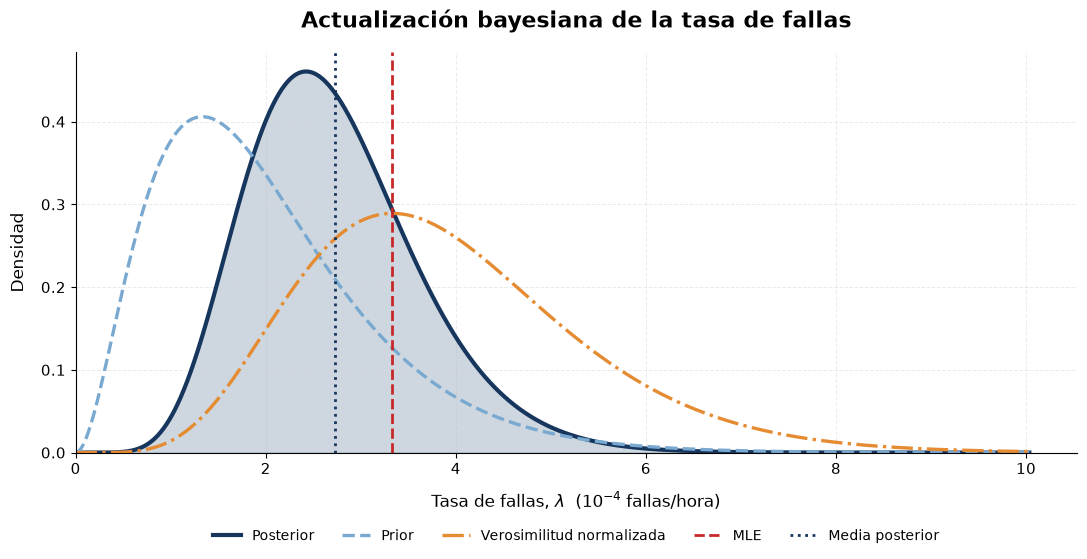

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------------------------------------
# Distribuciones
# ----------------------------------------------------------

prior_dist = stats.gamma(
    a=alpha0,
    scale=1 / beta0
)

likelihood_dist = stats.gamma(
    a=r + 1,
    scale=1 / T
)

posterior_dist = stats.gamma(
    a=alpha_n,
    scale=1 / beta_n
)

# Rango que contiene prácticamente toda la masa probabilística
lambda_max = max(
    prior_dist.ppf(0.999),
    likelihood_dist.ppf(0.999),
    posterior_dist.ppf(0.999)
)

lambda_grid = np.linspace(1e-10, lambda_max, 2000)

# Densidades
prior_pdf = prior_dist.pdf(lambda_grid)
like_pdf = likelihood_dist.pdf(lambda_grid)
post_pdf = posterior_dist.pdf(lambda_grid)

# ----------------------------------------------------------
# Transformación para presentar lambda en unidades de 10^-4
# ----------------------------------------------------------

factor = 1e4

x_plot = lambda_grid * factor

# La densidad debe transformarse con el mismo factor
prior_plot = prior_pdf / factor
like_plot = like_pdf / factor
post_plot = post_pdf / factor

# Estimadores
lambda_mle = r / T
lambda_post_mean = alpha_n / beta_n

# ----------------------------------------------------------
# Gráfica
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.8))

# Posterior: distribución principal
ax.fill_between(
    x_plot,
    post_plot,
    color="#244A73",
    alpha=0.22
)

ax.plot(
    x_plot,
    post_plot,
    color="#17365D",
    linewidth=3,
    label="Posterior"
)

# Prior: línea azul clara
ax.plot(
    x_plot,
    prior_plot,
    color="#79A9D1",
    linewidth=2.4,
    linestyle="--",
    label="Prior"
)

# Verosimilitud: línea naranja
ax.plot(
    x_plot,
    like_plot,
    color="#E58B32",
    linewidth=2.4,
    linestyle="-.",
    label="Verosimilitud normalizada"
)

# MLE
ax.axvline(
    lambda_mle * factor,
    color="#C62828",
    linestyle="--",
    linewidth=2,
    label="MLE"
)

# Media posterior
ax.axvline(
    lambda_post_mean * factor,
    color="#17365D",
    linestyle=":",
    linewidth=2,
    label="Media posterior"
)

# ----------------------------------------------------------
# Formato
# ----------------------------------------------------------

ax.set_title(
    "Actualización bayesiana de la tasa de fallas",
    fontsize=16,
    fontweight="semibold",
    pad=18
)

ax.set_xlabel(
    r"Tasa de fallas, $\lambda$  ($10^{-4}$ fallas/hora)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Densidad",
    fontsize=12,
    labelpad=10
)

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Solo cuadrícula horizontal para evitar ruido visual
ax.grid(
    axis="y",
    color="#D9D9D9",
    linestyle="--",
    linewidth=0.7,
    alpha=0.55
)

# Eliminar bordes innecesarios
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leyenda fuera del área de datos
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=5,
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [6]:
# Muestreo posterior y variables derivadas
lambda_s = stats.gamma.rvs(alpha_n, scale=1/beta_n, size=50000, random_state=2026)
mtbf_s = 1/lambda_s
res_exp=pd.concat([summary(lambda_s,"λ posterior"),summary(mtbf_s,"MTBF posterior")],axis=1).T
res_exp

,media,mediana,desv,HDI 2.5%,HDI 97.5%
λ posterior,0.000273,0.000264,0.000091,0.000115,0.000458
MTBF posterior,4115.829038,3793.160819,1560.504252,1789.790286,7175.662220


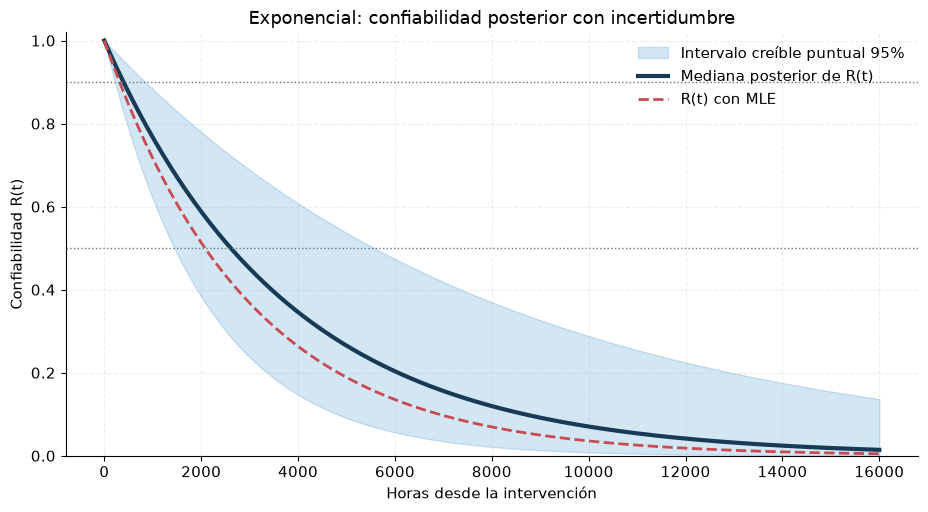

In [7]:
# Distribución posterior predictiva de confiabilidad
hours=np.linspace(0,16000,400)
R_s=np.exp(-lambda_s[:8000,None]*hours[None,:])
R_med=np.median(R_s,axis=0); R_lo,R_hi=np.percentile(R_s,[2.5,97.5],axis=0)
fig,ax=plt.subplots(figsize=(11,5.5))
ax.fill_between(hours,R_lo,R_hi,color=COLORS['blue'],alpha=.2,label='Intervalo creíble puntual 95%')
ax.plot(hours,R_med,color=COLORS['navy'],lw=3,label='Mediana posterior de R(t)')
ax.plot(hours,np.exp(-lambda_mle*hours),color=COLORS['red'],ls='--',lw=2,label='R(t) con MLE')
for target in [0.9,0.5]: ax.axhline(target,color=COLORS['gray'],ls=':',lw=1)
ax.set(xlabel='Horas desde la intervención',ylabel='Confiabilidad R(t)',title='Exponencial: confiabilidad posterior con incertidumbre',ylim=(0,1.02))
ax.legend(frameon=False); plt.show()

## 4. Sensibilidad al prior

Un análisis bayesiano responsable no presenta un solo prior como si fuera incuestionable. A continuación se comparan tres priors con la misma jerarquía de unidades pero distinta fuerza:

- **Débil:** poca información equivalente.
- **Base:** experiencia del fabricante.
- **Optimista fuerte:** prior concentrado en una tasa menor.

Si la posterior cambia de forma material entre priors plausibles, la decisión debe reconocer esa dependencia.

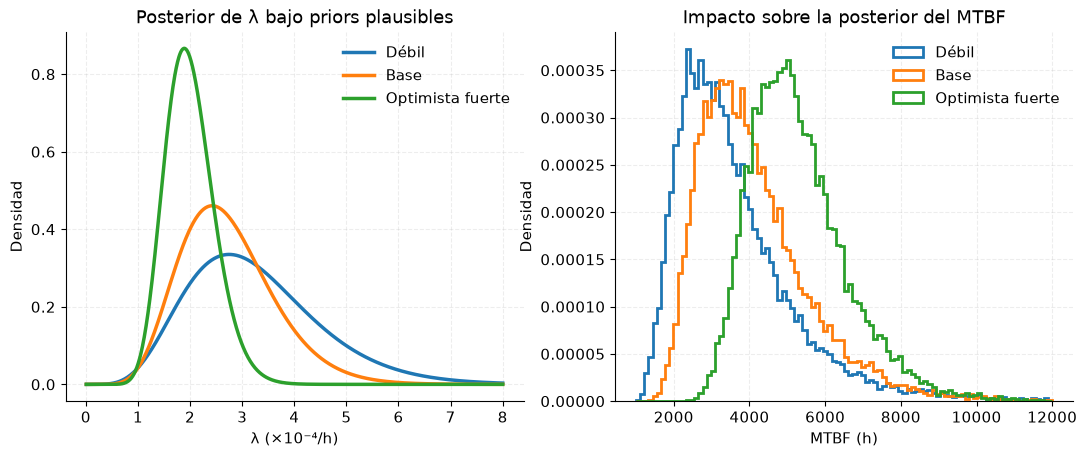

In [8]:
priors={"Débil":(0.5,2000),"Base":(3,15000),"Optimista fuerte":(12,72000)}
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for label,(a,b) in priors.items():
    post=stats.gamma.pdf(lambda_grid,a+r,scale=1/(b+T))
    axes[0].plot(lambda_grid*1e4,post/1e4,lw=2.5,label=label)
    samp=stats.gamma.rvs(a+r,scale=1/(b+T),size=20000,random_state=int(a*100+1))
    axes[1].hist(1/samp,bins=100,density=True,histtype='step',lw=2,label=label,range=(1000,12000))
axes[0].set(title='Posterior de λ bajo priors plausibles',xlabel='λ (×10⁻⁴/h)',ylabel='Densidad')
axes[1].set(title='Impacto sobre la posterior del MTBF',xlabel='MTBF (h)',ylabel='Densidad')
for ax in axes: ax.legend(frameon=False)
plt.show()

# Parte B. Modelo Weibull

## 5. Modelo, censura y parámetros

Para $T\sim Weibull(k,\eta)$, con forma $k>0$ y escala $\eta>0$:

$$f(t\mid k,\eta)=\frac{k}{\eta}\left(\frac{t}{\eta}\right)^{k-1}\exp\left[-\left(\frac{t}{\eta}\right)^k\right],$$

$$R(t\mid k,\eta)=\exp\left[-\left(\frac{t}{\eta}\right)^k\right],\qquad
h(t\mid k,\eta)=\frac{k}{\eta}\left(\frac{t}{\eta}\right)^{k-1}.$$

- $k<1$: riesgo decreciente, común en fallas tempranas.
- $k=1$: riesgo constante, equivalente al Exponencial.
- $k>1$: riesgo creciente, compatible con desgaste.

Con indicador $\delta_i=1$ para falla y $0$ para censura a la derecha, cada observación contribuye:

$$L_i=f(t_i)^{\delta_i}R(t_i)^{1-\delta_i}.$$

La censura **no es ausencia de información**. Una unidad censurada informa que sobrevivió al menos hasta $t_i$.

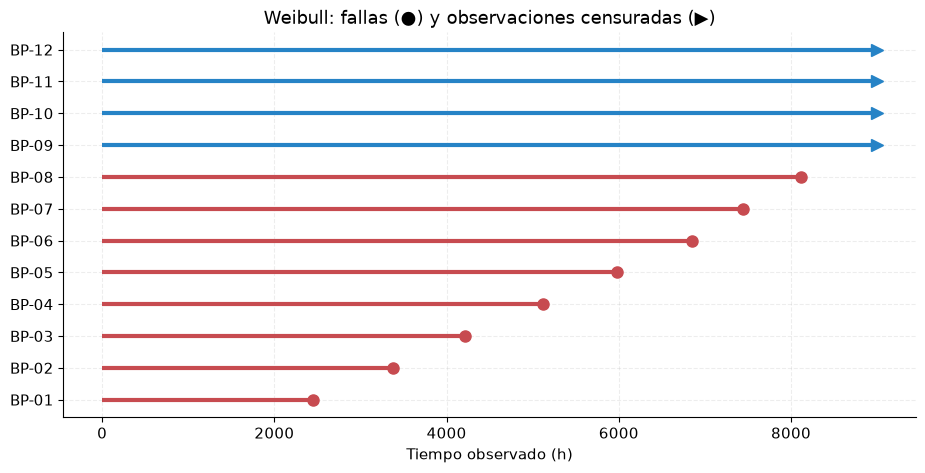

In [9]:
# Visualización de los datos censurados
fig,ax=plt.subplots(figsize=(11,5))
for i,row in weibull_data.iterrows():
    c=COLORS['red'] if row.evento==1 else COLORS['blue']
    ax.hlines(i,0,row.tiempo_h,color=c,lw=3)
    ax.plot(row.tiempo_h,i,'o' if row.evento==1 else '>',color=c,ms=8)
ax.set_yticks(range(len(weibull_data))); ax.set_yticklabels(weibull_data.equipo)
ax.set(xlabel='Tiempo observado (h)',title='Weibull: fallas (●) y observaciones censuradas (▶)')
plt.show()

## 6. Conjugación condicional de Weibull

Weibull no tiene, en general, una conjugada bidimensional sencilla para $(k,\eta)$. Sin embargo, si $k$ es conocido, definimos:

$$q=\eta^{-k}.$$

La verosimilitud, ignorando términos que no dependen de $q$, queda:

$$L(q\mid k,D)\propto q^r\exp\left[-q\sum_i t_i^k\right].$$

Con prior $q\sim Gamma(a_0,b_0)$:

$$\boxed{q\mid k,D\sim Gamma\left(a_0+r,\ b_0+\sum_i t_i^k\right)}.$$

Esto es **conjugación condicional**: la actualización es exacta si fijamos $k$, pero deja de serlo cuando $k$ también es desconocido.

In [10]:
k_fixed=2.0
t=weibull_data.tiempo_h.to_numpy(); d=weibull_data.evento.to_numpy(); r_w=d.sum()
a0=2.0
eta_prior=8500.0
# Elegimos b0 para que E[q]=a0/b0=eta_prior^{-k}
b0=a0*eta_prior**k_fixed
S=np.sum(t**k_fixed)
a_n,b_n=a0+r_w,b0+S
q_s=stats.gamma.rvs(a_n,scale=1/b_n,size=50000,random_state=11)
eta_s=q_s**(-1/k_fixed)
print(f"r={r_w}; Σtᵢ^k={S:,.3e}")
print(f"Posterior q|k,D = Gamma({a_n:.1f}, {b_n:.3e})")
display(summary(eta_s,"η | k=2"))

r=8; Σtᵢ^k=5.893e+08
Posterior q|k,D = Gamma(10.0, 7.338e+08)


media         8897.448405
mediana       8706.539271
desv          1492.908400
HDI 2.5%      6330.110308
HDI 97.5%    11925.203809
Name: η | k=2, dtype: float64

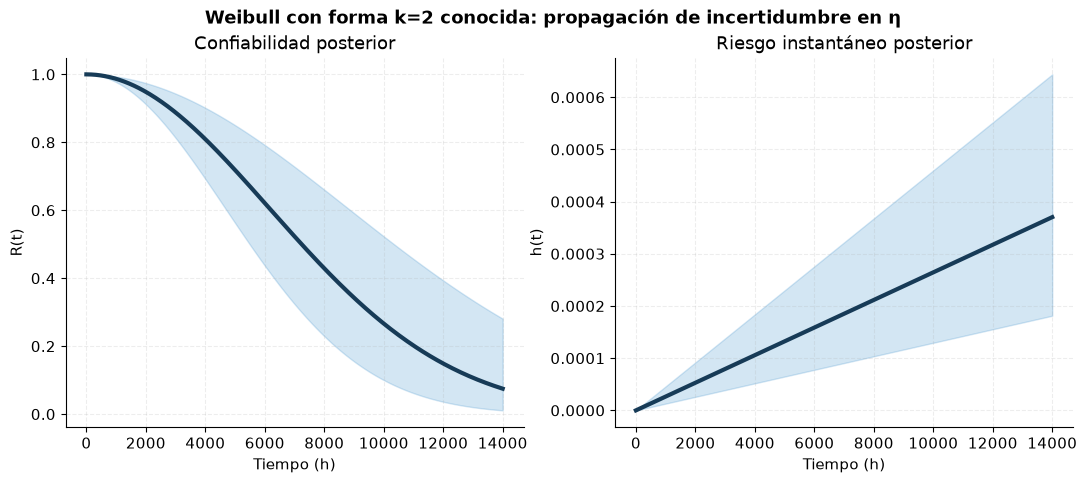

In [11]:
# Confiabilidad y hazard con k fijo
x=np.linspace(0,14000,350)
R=np.exp(-(x[None,:]/eta_s[:7000,None])**k_fixed)
h=(k_fixed/eta_s[:7000,None])*(x[None,:]/eta_s[:7000,None])**(k_fixed-1)
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,Y,title,ylabel in [(axes[0],R,'Confiabilidad posterior','R(t)'),(axes[1],h,'Riesgo instantáneo posterior','h(t)')]:
    med=np.median(Y,axis=0);lo,hi=np.percentile(Y,[2.5,97.5],axis=0)
    ax.fill_between(x,lo,hi,color=COLORS['blue'],alpha=.2)
    ax.plot(x,med,color=COLORS['navy'],lw=3)
    ax.set(title=title,xlabel='Tiempo (h)',ylabel=ylabel)
plt.suptitle('Weibull con forma k=2 conocida: propagación de incertidumbre en η',fontweight='bold')
plt.show()

## 7. Weibull con forma y escala desconocidas: posterior por grilla

Para profundizar sin depender de un motor MCMC, calcularemos la posterior exacta sobre una grilla densa. Usamos priors independientes sobre escalas logarítmicas:

$$\log k\sim N(\mu_k,\sigma_k^2),\qquad \log\eta\sim N(\mu_\eta,\sigma_\eta^2).$$

La log-verosimilitud censurada es:

$$\ell(k,\eta)=\sum_i\delta_i\left[\log k-k\log\eta+(k-1)\log t_i\right]-\sum_i(t_i/\eta)^k.$$

La grilla permite ver algo que un único estimador no muestra: la **dependencia posterior entre forma y escala**.

In [12]:
k_grid=np.linspace(.55,4.2,260)
eta_grid=np.linspace(4500,15000,300)
K,E=np.meshgrid(k_grid,eta_grid,indexing='ij')
# Log-likelihood vectorizada
logL=np.zeros_like(K)
for ti,di in zip(t,d):
    logL += di*(np.log(K)-K*np.log(E)+(K-1)*np.log(ti))-(ti/E)**K
# Priors lognormales: mediana k=1.7, eta=9000
logPrior=stats.norm.logpdf(np.log(K),np.log(1.7),0.52)-np.log(K)
logPrior+=stats.norm.logpdf(np.log(E),np.log(9000),0.38)-np.log(E)
logPost=logL+logPrior; logPost-=special.logsumexp(logPost)
P=np.exp(logPost)
# Muestreo discreto de la posterior
idx=RNG.choice(P.size,size=50000,p=P.ravel())
ki,ei=np.unravel_index(idx,P.shape); k_s=k_grid[ki]; eta2_s=eta_grid[ei]
summary_weib=pd.concat([summary(k_s,'k'),summary(eta2_s,'η')],axis=1).T
summary_weib

,media,mediana,desv,HDI 2.5%,HDI 97.5%
k,2.002057,1.945174,0.551822,1.015058,3.114865
η,9013.748428,8784.280936,1572.943985,6255.852843,12331.103679


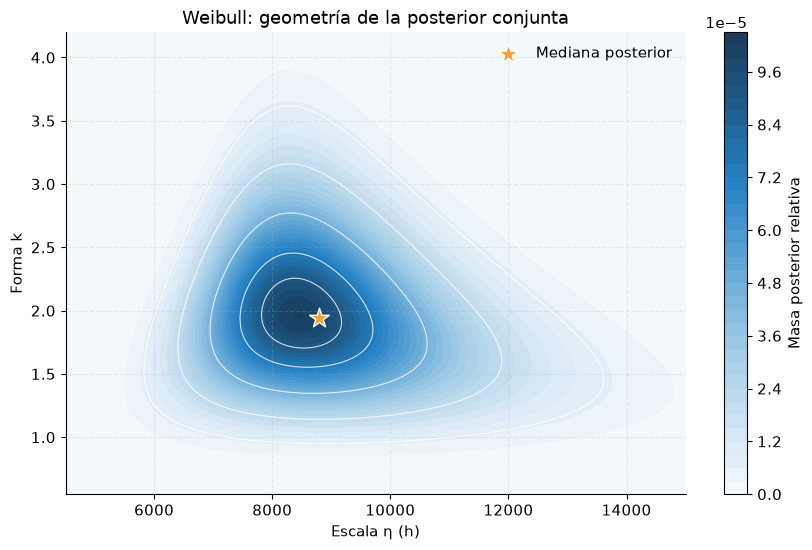

In [13]:
fig,ax=plt.subplots(figsize=(10,6))
levels=np.quantile(P[P>0],[.65,.80,.90,.96,.985])
cf=ax.contourf(E,K,P,levels=35,cmap=CMAP)
ax.contour(E,K,P,levels=levels,colors='white',linewidths=.8,alpha=.8)
ax.scatter(np.median(eta2_s),np.median(k_s),marker='*',s=220,color=COLORS['orange'],edgecolor='white',label='Mediana posterior')
ax.set(xlabel='Escala η (h)',ylabel='Forma k',title='Weibull: geometría de la posterior conjunta')
fig.colorbar(cf,ax=ax,label='Masa posterior relativa');ax.legend(frameon=False);plt.show()

/tmp/ipykernel_2898992/2530783238.py:4: RuntimeWarning: divide by zero encountered in power
  hpred=(k_s[sel,None]/eta2_s[sel,None])*(x[None,:]/eta2_s[sel,None])**(k_s[sel,None]-1)


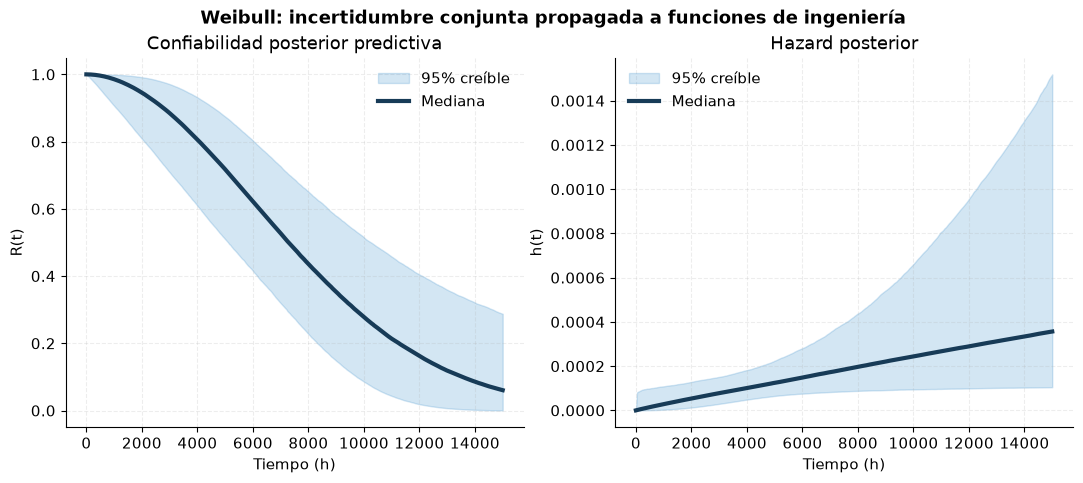

In [14]:
# Posterior predictive: confiabilidad y hazard integrando k y eta
x=np.linspace(0,15000,380); sel=RNG.choice(len(k_s),6000,replace=False)
Rpred=np.exp(-(x[None,:]/eta2_s[sel,None])**k_s[sel,None])
hpred=(k_s[sel,None]/eta2_s[sel,None])*(x[None,:]/eta2_s[sel,None])**(k_s[sel,None]-1)
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for ax,Y,title,ylabel in [(axes[0],Rpred,'Confiabilidad posterior predictiva','R(t)'),(axes[1],hpred,'Hazard posterior','h(t)')]:
    med=np.median(Y,0);lo,hi=np.percentile(Y,[2.5,97.5],axis=0)
    ax.fill_between(x,lo,hi,color=COLORS['blue'],alpha=.2,label='95% creíble')
    ax.plot(x,med,color=COLORS['navy'],lw=3,label='Mediana')
    ax.set(title=title,xlabel='Tiempo (h)',ylabel=ylabel);ax.legend(frameon=False)
plt.suptitle('Weibull: incertidumbre conjunta propagada a funciones de ingeniería',fontweight='bold');plt.show()

# Parte C. Modelo Lognormal con prior Normal–Gamma inversa

## 8. Transformación logarítmica y mantenibilidad

Si $T_R$ es el tiempo de reparación:

$$T_R\sim Lognormal(\mu,\sigma^2)\iff Y=\log T_R\sim N(\mu,\sigma^2).$$

La mantenibilidad es:

$$M(t)=P(T_R\le t)=\Phi\left(\frac{\log t-\mu}{\sigma}\right),$$

mientras que:

$$MTTR=E[T_R]=e^{\mu+\sigma^2/2}.$$

Cuando $\mu$ y $\sigma^2$ son desconocidos, una conjugada estándar es:

$$\sigma^2\sim InvGamma(\alpha_0,\beta_0),\qquad
\mu\mid\sigma^2\sim N\left(\mu_0,\frac{\sigma^2}{\kappa_0}\right).$$

Con $y_i=\log t_i$, los parámetros posteriores son:

$$\kappa_n=\kappa_0+n,$$
$$\mu_n=\frac{\kappa_0\mu_0+n\bar y}{\kappa_n},$$
$$\alpha_n=\alpha_0+\frac n2,$$
$$\beta_n=\beta_0+\frac12\sum_i(y_i-\bar y)^2+
\frac{\kappa_0n(\bar y-\mu_0)^2}{2\kappa_n}.$$

In [15]:
y=np.log(repair_data.ttr_h.to_numpy()); n_l=len(y); ybar=y.mean()
mu0=np.log(5.0); kappa0=2.0; alpha0_l=3.0; beta0_l=0.35
kappa_n=kappa0+n_l
mu_n=(kappa0*mu0+n_l*ybar)/kappa_n
alpha_n_l=alpha0_l+n_l/2
beta_n_l=beta0_l+.5*np.sum((y-ybar)**2)+(kappa0*n_l*(ybar-mu0)**2)/(2*kappa_n)
print(f"Posterior: κn={kappa_n:.2f}, μn={mu_n:.4f}, αn={alpha_n_l:.2f}, βn={beta_n_l:.4f}")
# Muestreo posterior jerárquico
sigma2_s=stats.invgamma.rvs(alpha_n_l,scale=beta_n_l,size=60000,random_state=19)
mu_s=stats.norm.rvs(loc=mu_n,scale=np.sqrt(sigma2_s/kappa_n),random_state=20)
sigma_s=np.sqrt(sigma2_s); mttr_s=np.exp(mu_s+sigma2_s/2)
p90_s=np.exp(mu_s+sigma_s*stats.norm.ppf(.90))
display(pd.concat([summary(mu_s,'μ'),summary(sigma_s,'σ'),summary(mttr_s,'MTTR'),summary(p90_s,'P90 reparación')],axis=1).T)

Posterior: κn=12.00, μn=1.6351, αn=8.00, βn=0.7866


,media,mediana,desv,HDI 2.5%,HDI 97.5%
μ,1.635589,1.635339,0.097099,1.441412,1.826451
σ,0.329141,0.320205,0.062738,0.218580,0.452172
MTTR,5.456198,5.408332,0.554967,4.400136,6.545230
P90 reparación,7.890059,7.724648,1.049789,6.149492,10.010531


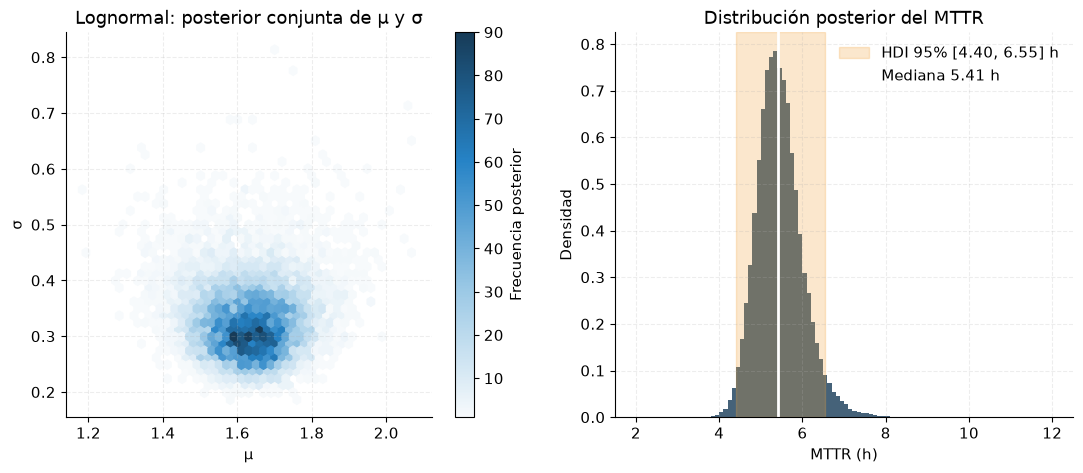

In [16]:
# Densidad conjunta posterior de mu y sigma
fig,axes=plt.subplots(1,2,figsize=(13,5))
h=axes[0].hexbin(mu_s[::6],sigma_s[::6],gridsize=45,cmap=CMAP,mincnt=1)
axes[0].set(xlabel='μ',ylabel='σ',title='Lognormal: posterior conjunta de μ y σ')
fig.colorbar(h,ax=axes[0],label='Frecuencia posterior')
axes[1].hist(mttr_s,bins=100,density=True,color=COLORS['navy'],alpha=.8,range=(2,12))
lo,hi=hdi(mttr_s);axes[1].axvspan(lo,hi,color=COLORS['orange'],alpha=.25,label=f'HDI 95% [{lo:.2f}, {hi:.2f}] h')
axes[1].axvline(np.median(mttr_s),color='white',lw=2,label=f'Mediana {np.median(mttr_s):.2f} h')
axes[1].set(xlabel='MTTR (h)',ylabel='Densidad',title='Distribución posterior del MTTR');axes[1].legend(frameon=False)
plt.show()

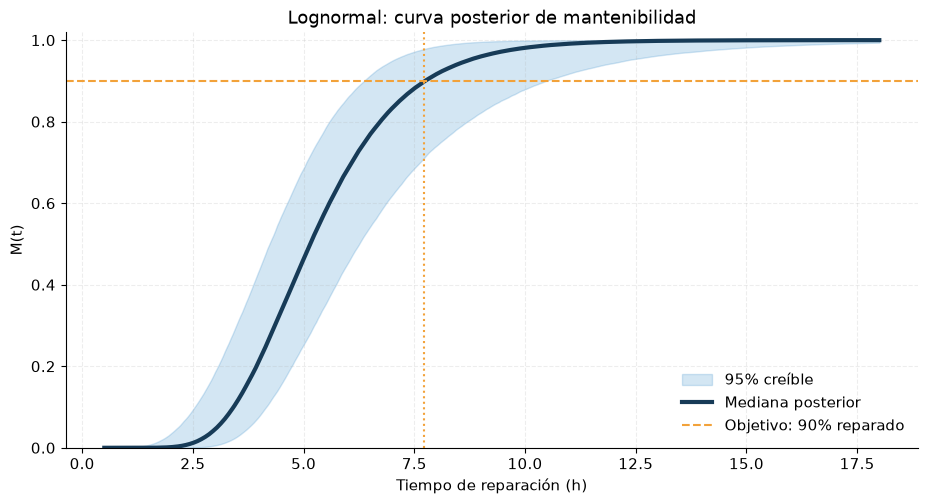

In [17]:
# Mantenibilidad posterior
tr=np.linspace(.5,18,400); sel=RNG.choice(len(mu_s),7000,replace=False)
M=stats.norm.cdf((np.log(tr)[None,:]-mu_s[sel,None])/sigma_s[sel,None])
med=np.median(M,0);lo,hi=np.percentile(M,[2.5,97.5],axis=0)
fig,ax=plt.subplots(figsize=(11,5.4))
ax.fill_between(tr,lo,hi,color=COLORS['blue'],alpha=.2,label='95% creíble')
ax.plot(tr,med,color=COLORS['navy'],lw=3,label='Mediana posterior')
ax.axhline(.9,color=COLORS['orange'],ls='--',label='Objetivo: 90% reparado')
ax.axvline(np.median(p90_s),color=COLORS['orange'],ls=':')
ax.set(xlabel='Tiempo de reparación (h)',ylabel='M(t)',title='Lognormal: curva posterior de mantenibilidad',ylim=(0,1.02))
ax.legend(frameon=False);plt.show()

## 9. Comparación compacta: Bayes frente a máxima verosimilitud

La comparación debe hacerse con el mismo objeto de interés:

- parámetros $\lambda$, $(k,\eta)$ o $(\mu,\sigma)$;
- funciones de ingeniería $R(t)$, $h(t)$, $MTBF$ o $M(t)$;
- incertidumbre predictiva;
- sensibilidad a supuestos y priors.

En muestras pequeñas, el estimador bayesiano puede ser más estable porque regulariza con información previa. En muestras grandes, la verosimilitud suele dominar. Sin embargo, ni Bayes ni MLE protegen frente a un modelo de distribución mal elegido.

In [18]:
# MLE Weibull censurado y Lognormal para una tabla comparativa
def nll_weib(z):
    k,eta=np.exp(z)
    return -np.sum(d*(np.log(k)-k*np.log(eta)+(k-1)*np.log(t))-(t/eta)**k)
fit=minimize(nll_weib,np.log([1.7,8500]),method='Nelder-Mead')
k_mle,eta_mle=np.exp(fit.x)
mu_mle=y.mean(); sigma_mle=np.sqrt(np.mean((y-y.mean())**2)); mttr_mle=np.exp(mu_mle+sigma_mle**2/2)
comparison=pd.DataFrame({
    'Modelo':['Exponencial','Weibull','Lognormal'],
    'Bayes':['λ media {:.3e}; MTBF mediana {:.0f} h'.format(lambda_s.mean(),np.median(mtbf_s)),
             'k mediana {:.2f}; η mediana {:.0f} h'.format(np.median(k_s),np.median(eta2_s)),
             'MTTR mediana {:.2f} h'.format(np.median(mttr_s))],
    'MLE':['λ {:.3e}; MTBF {:.0f} h'.format(lambda_mle,1/lambda_mle),
           'k {:.2f}; η {:.0f} h'.format(k_mle,eta_mle),
           'MTTR {:.2f} h'.format(mttr_mle)]
})
comparison

,Modelo,Bayes,MLE
0,Exponencial,λ media 2.732e-04; MTBF mediana 3793 h,λ 3.333e-04; MTBF 3000 h
1,Weibull,k mediana 1.95; η mediana 8784 h,k 2.30; η 8471 h
2,Lognormal,MTTR mediana 5.41 h,MTTR 5.39 h


## 10. Diagnóstico conceptual y recomendaciones

### Exponencial
Use cuando sea defendible una tasa aproximadamente constante. La conjugación Gamma–Exponencial es completa y permite actualización exacta con fallas y horas acumuladas.

### Weibull
Use cuando se requiera distinguir fallas tempranas, aleatorias y desgaste. Con forma conocida existe conjugación condicional sobre $q=\eta^{-k}$. Con forma desconocida conviene usar grilla, MCMC o inferencia variacional, y revisar correlación posterior y sensibilidad al prior.

### Lognormal
Es útil para tiempos positivos y asimétricos, particularmente tiempos de reparación. En escala logarítmica, el modelo Normal con prior Normal–Gamma inversa permite actualizar conjuntamente localización y dispersión.

### Controles mínimos de calidad
1. Revisar unidad y definición del tiempo cero.
2. Diferenciar falla, suspensión y censura.
3. Separar modos de falla físicamente distintos.
4. Justificar independencia o modelar efectos comunes.
5. Documentar el prior y su equivalente muestral.
6. Ejecutar sensibilidad a priors y distribuciones alternativas.
7. Validar predicciones fuera de muestra cuando existan datos suficientes.

## 11. Ejercicio de extensión

1. Agregue dos fallas y 5.000 horas de exposición al modelo Exponencial. Actualice la posterior sin reutilizar los datos originales.
2. Cambie el prior de $k$ en Weibull y cuantifique el cambio en $R(10.000)$.
3. Agregue una reparación de 20 horas al modelo Lognormal. Compare el efecto sobre media, mediana y P90 del tiempo de reparación.
4. Defina un costo por parada no planificada y construya una distribución posterior del costo anual.

---

## Referencias

- NIST/SEMATECH e-Handbook of Statistical Methods, secciones de modelos de vida Exponencial y Weibull.
- Gelman, Carlin, Stern, Dunson, Vehtari y Rubin. *Bayesian Data Analysis*, 3.ª edición.
- Meeker, Escobar y Pascual. *Statistical Methods for Reliability Data*, 2.ª edición.
- Material suministrado por el usuario: `probabilidad_condicional_bayes_confiabilidad.html` y `probabilidad_bayes_actualizacion_mantenibilidad.html`.